#### Credit Card Fraud Detection Model


In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,HistGradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


c:\Users\Dilsh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#configaration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set_style(style='darkgrid')


##### lode data set


In [ ]:
df=pd.read_csv(r"C:\Users\Dilsh\Desktop\Machin_Learning\Data_sets\creditcard.csv")

#### EDA


In [4]:
df.shape

(284807, 31)

In [5]:
df.head(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
# check missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# check the encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(5))

Time
163152.000    36
64947.000     26
68780.000     25
3767.000      21
3770.000      20
Name: count, dtype: int64
V1
1.246    77
2.056    77
2.053    62
1.302    60
2.040    53
Name: count, dtype: int64
V2
0.167     77
-0.327    77
0.090     62
-0.607    60
-0.147    53
Name: count, dtype: int64
V3
0.488     77
-2.752    77
-1.682    62
-0.682    60
-2.956    53
Name: count, dtype: int64
V4
0.635     77
-0.842    77
0.454     62
-1.905    60
-0.578    53
Name: count, dtype: int64
V5
-0.563    77
2.463     77
0.298     62
1.327     60
2.609     53
Name: count, dtype: int64
V6
-1.011    77
3.174     77
-0.954    62
3.436     60
3.143     53
Name: count, dtype: int64
V7
0.015     77
-0.432    77
0.152     62
-1.145    60
-0.417    53
Name: count, dtype: int64
V8
-0.160    77
0.728     77
-0.207    62
0.959     60
0.784     53
Name: count, dtype: int64
V9
0.170    77
0.609    77
0.587    62
1.671    60
0.360    53
Name: count, dtype: int64
V10
-0.045    77
-0.075    77
-0.362    62
-1.02

In [9]:
# check duplicate values
df.duplicated().sum()

np.int64(1081)

In [10]:
duplicated_columns = []

for col in df.columns:
    if df[col].duplicated().any():
        duplicated_columns.append(col)

print("Columns with duplicates:", duplicated_columns)

Columns with duplicates: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [11]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [12]:
print(df['Class'].value_counts())
print("--"*50)
print(df['Class'].value_counts(normalize=True)*100)


Class
0    284315
1       492
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Class
0   99.827
1    0.173
Name: proportion, dtype: float64


##### this data set is highly imbalanced data set

In [13]:
# check hoe may duplicate values in eatch class
print("Number of duplicate values in Class 0:", df[df['Class'] == 0].duplicated().sum())
print("Number of duplicate values in Class 1:", df[df['Class'] == 1].duplicated().sum())

Number of duplicate values in Class 0: 1062
Number of duplicate values in Class 1: 19


In [14]:
# drop duplicate values in class 0
df = df[~((df['Class'] == 0) & (df.duplicated()))]

In [15]:
# imbalanced ratio of dataset
n_fraud=(df['Class']==1).sum()
n_non_fraud=(df['Class']==0).sum()
# calculate the ratio of fraud to non-fraud transactions
print(round(n_non_fraud/max(n_fraud, 1), 4))


575.7175


##### That means for every 1 fraud case, there are about 576 normal transactions.

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283745.000,94810.630,47479.710,0.000,54208.000,84695.000,139297.000,172792.000
V1,283745.000,0.005,1.951,-56.408,-0.916,0.020,1.316,2.455
V2,283745.000,-0.004,1.649,-72.716,-0.600,0.064,0.800,22.058
V3,283745.000,0.001,1.515,-48.326,-0.890,0.180,1.027,9.383
V4,283745.000,-0.003,1.415,-5.683,-0.850,-0.022,0.740,16.875
V5,283745.000,0.001,1.379,-113.743,-0.690,-0.054,0.612,34.802
V6,283745.000,-0.001,1.332,-26.161,-0.769,-0.275,0.397,73.302
V7,283745.000,0.001,1.236,-43.557,-0.553,0.041,0.570,120.589
V8,283745.000,-0.001,1.190,-73.217,-0.209,0.022,0.326,20.007
V9,283745.000,-0.002,1.096,-13.434,-0.644,-0.053,0.596,15.595


##### Data Visualization

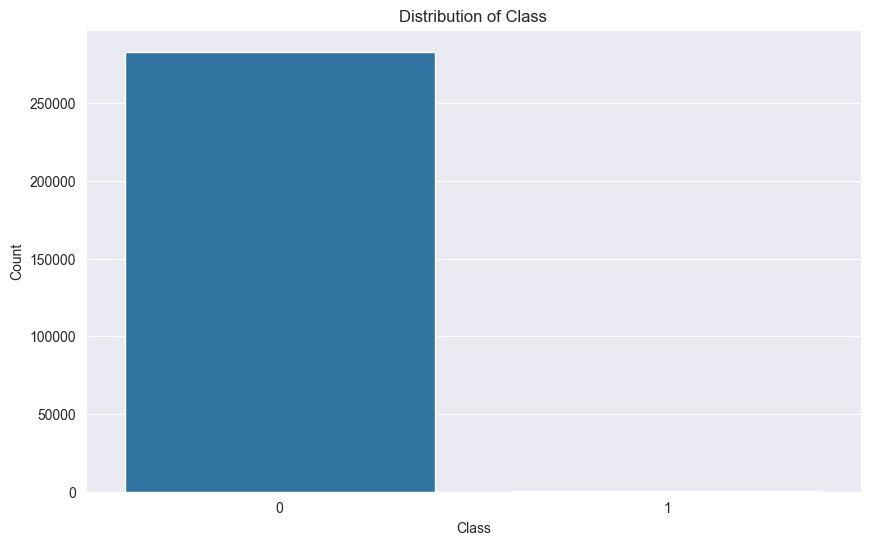

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(x="Class", data = df)
plt.title("Distribution of Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

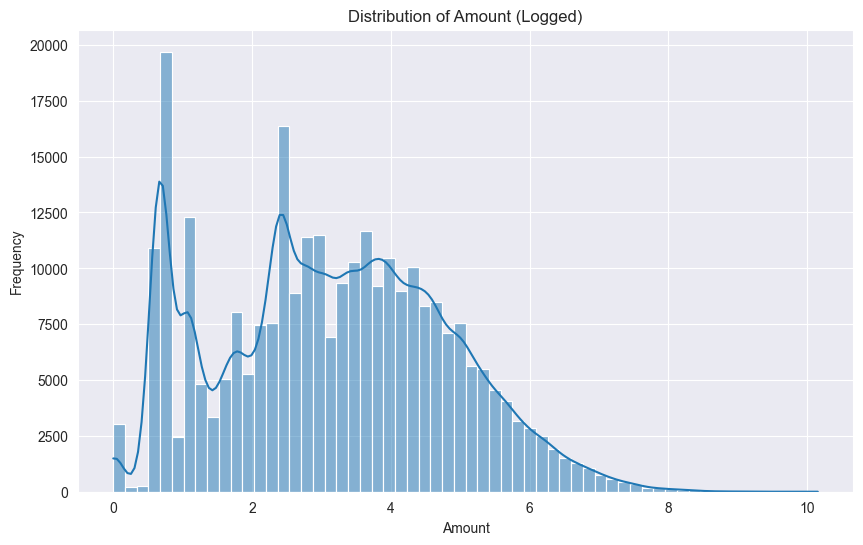

In [18]:
# Amount distribution
plt.figure(figsize=(10,6))
sns.histplot(np.log1p(df['Amount']), bins=60, kde=True)
plt.title("Distribution of Amount (Logged)")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()  

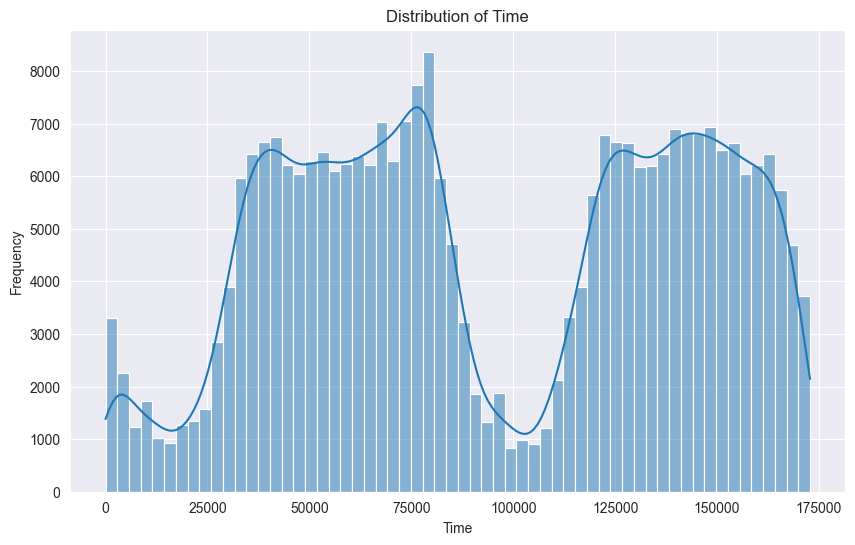

In [19]:
#time distribution
plt.figure(figsize=(10,6))
sns.histplot(df['Time'], bins=60, kde=True)
plt.title("Distribution of Time")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()  

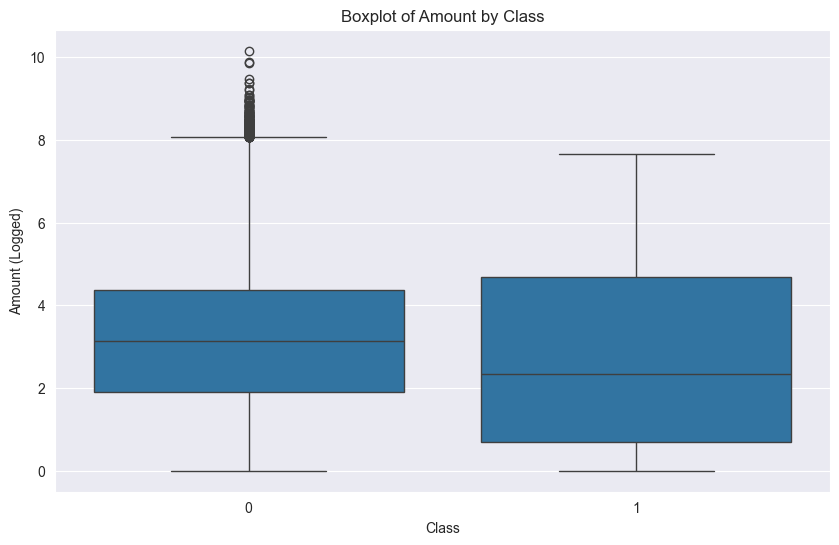

In [20]:
#amount distribution by class
plt.figure(figsize=(10,6))
sns.boxplot(x='Class', y=np.log1p(df['Amount']), data=df)
plt.title("Boxplot of Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount (Logged)")
plt.show()

<Axes: >

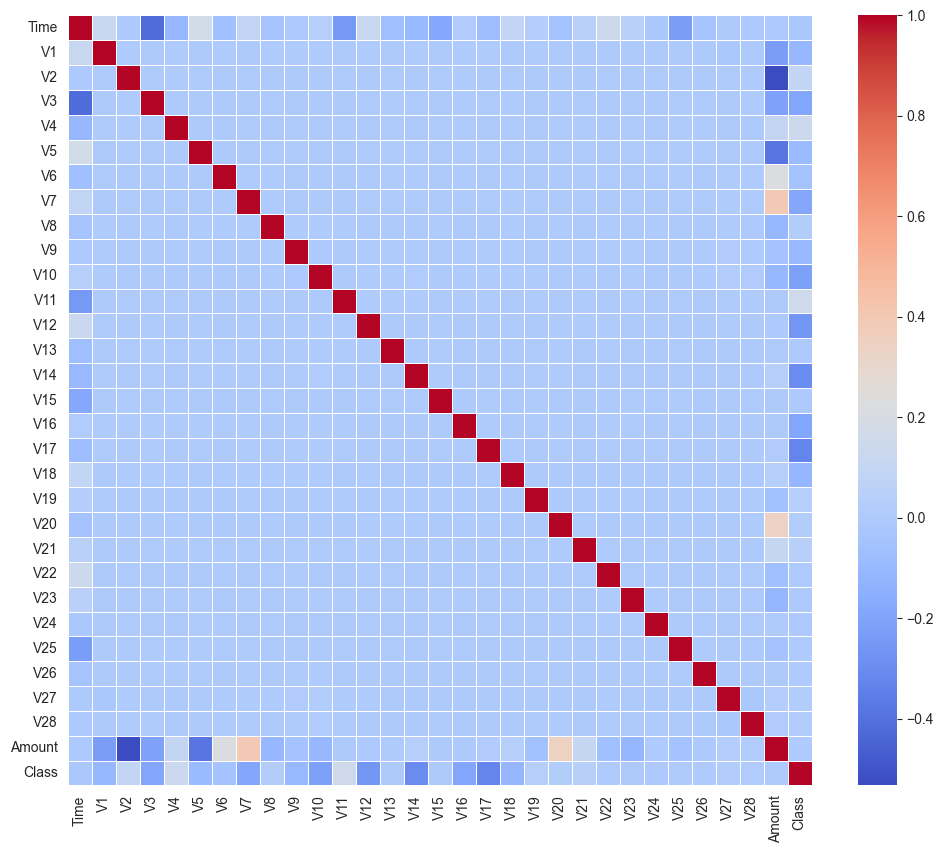

In [21]:
 #corelation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)

##### This data set is pca apply data set .so there are no highly correlated columns

In [22]:
# corelation with target variable
corr_target=df.corr(numeric_only=True)['Class'].sort_values(ascending=False)
print(corr_target.head(10) ,"\n\n", corr_target.tail(10) )

Class   1.000
V11     0.155
V4      0.134
V2      0.092
V21     0.041
V19     0.035
V20     0.020
V8      0.020
V27     0.018
V28     0.010
Name: Class, dtype: float64 

 V9    -0.098
V1    -0.102
V18   -0.112
V7    -0.188
V3    -0.194
V16   -0.197
V10   -0.219
V12   -0.261
V14   -0.304
V17   -0.327
Name: Class, dtype: float64


##### Data Preprocessing

In [23]:
# create a new column for log-transformed Amount
df['Amount_log']=np.log1p(df['Amount'])


In [24]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Amount_log'],
      dtype='str')

In [25]:
# prepare data for modeling
x=df.drop(['Class','Amount'], axis=1)
y=df['Class']

In [26]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [90]:
#save the x_train, x_test, y_train, y_test
import joblib
joblib.dump(x_train, "x_train.pkl")
joblib.dump(x_test, "x_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

##### Base line model

In [27]:
base_pipline=Pipeline(
    [   
        ('model',DecisionTreeClassifier( random_state=42))


    ]
)

In [28]:
# train the model
base_pipline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If f

In [29]:
y_train_pred=base_pipline.predict(x_train)
y_test_pred=base_pipline.predict(x_test)

In [30]:
#get accuracy
from sklearn.metrics import accuracy_score


base_train_accuracy=accuracy_score(y_train, y_train_pred)
base_test_accuracy=accuracy_score(y_test, y_test_pred) 
 

In [31]:
print(f"Base Train Accuracy: {base_train_accuracy:.4f}")
print(f"Base Test Accuracy: {base_test_accuracy:.4f}")

Base Train Accuracy: 1.0000
Base Test Accuracy: 0.9990


In [32]:
# CLASSIFICATION REPORT
print("Classification Report for Train Set:")
print(classification_report(y_train, y_train_pred))

Classification Report for Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    226602
           1       1.00      1.00      1.00       394

    accuracy                           1.00    226996
   macro avg       1.00      1.00      1.00    226996
weighted avg       1.00      1.00      1.00    226996



In [33]:
#classification report for test set
print("Classification Report for Test Set:")
print(classification_report(y_test,y_test_pred))

Classification Report for Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.65      0.68        98

    accuracy                           1.00     56749
   macro avg       0.86      0.83      0.84     56749
weighted avg       1.00      1.00      1.00     56749



##### Accuracy score is not reliable becase of clas imbalance

In [38]:
from sklearn.metrics import average_precision_score

#average precision for train set
y_train_prob=base_pipline.predict_proba(x_train)[:,1]
print(f"Train Average Precision: {average_precision_score(y_train, y_train_prob):.4f}")

Train Average Precision: 1.0000


In [40]:
# average test set precision
y_test_prob=base_pipline.predict_proba(x_test)[:,1]
print(f"Test Precision: {average_precision_score(y_test, y_test_prob):.4f}")


Test Precision: 0.4702


##### Model optimization

In [52]:
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [59]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42,class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42,class_weight='balanced'),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42,class_weight='balanced')
    
}

In [61]:
for name,m  in  models.items():
    pr_auc_scores=[]

    for train_idx,test_idx in cv.split(x_train, y_train):
        x_train_fold, x_test_fold = x_train.iloc[train_idx], x_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        m.fit(x_train_fold, y_train_fold)
        y_test_prob=m.predict_proba(x_test_fold)[:,1]

        pr_auc=average_precision_score(y_test_fold, y_test_prob)
        pr_auc_scores.append(pr_auc)

    print(f"Model name:", name)
    print(f"pr_auc_scores:", pr_auc_scores)
    print(f"Mean pr_auc_score:", np.mean(pr_auc_scores))
    print("-"*50)




Model name: Decision Tree
pr_auc_scores: [0.6210502629898613, 0.608772816868443, 0.5879510868610556, 0.6614117244744098, 0.5438939029666645]
Mean pr_auc_score: 0.6046159588320869
--------------------------------------------------
Model name: Random Forest
pr_auc_scores: [0.8447489500348822, 0.8800795669818848, 0.8723581625275804, 0.8652109577956536, 0.8770328885224148]
Mean pr_auc_score: 0.8678861051724832
--------------------------------------------------
Model name: HistGradientBoosting
pr_auc_scores: [0.7258053197756433, 0.8082280583217425, 0.7823957603716737, 0.8055158637234201, 0.7668962552566977]
Mean pr_auc_score: 0.7777682514898354
--------------------------------------------------


**best model as per model selection process:Random Forest Classifier**

*Hyper parameater tuning for Random Forest Classifier*

In [72]:
# correct pipeline
rfc_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

In [73]:
# hyperparameter space
param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_leaf": [1, 2, 18, 20],
    "model__max_features": ["sqrt", "log2", 0.5]
}

In [74]:
#randomized search cv
random_search = RandomizedSearchCV(
    estimator=rfc_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="average_precision",
    verbose=2,
    n_jobs=-1
)

In [ ]:
best_rfc=Pipeline(
    [
        (
            "model",RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                max_depth=20,
                max_features=0.5,
                random_state=42,
                class_weight="balanced_subsample",
                n_jobs=-1

            )
        )
    ]
)

In [75]:
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__n_estimators': [200, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-va

In [76]:
print("Best parameters:", random_search.best_params_)
print(f"Best Average Precision: {random_search.best_score_:.4f}")

Best parameters: {'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': None}
Best Average Precision: 0.8718


*Re-train with best parameters*

In [77]:
best_rfc=Pipeline(
    [
        (
            "model",RandomForestClassifier(
                n_estimators=200,
                min_samples_leaf=2,
                max_depth=None,
                max_features="log2",
                random_state=42,
                class_weight="balanced_subsample",
                n_jobs=-1

            )
        )
    ]
)

In [78]:
best_rfc.fit(x_train, y_train) 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If 

In [85]:
#save the model
import joblib
joblib.dump(best_rfc, "best_random_forest_model.pkl")

['best_random_forest_model.pkl']